In [ ]:
!pip install scikit-learn stable-baselines3 gymnasium hmmlearn pandas numpy matplotlib --quiet

In [ ]:
# ==========================================================
# 0. IMPORTS & CONFIG
# ==========================================================
import io, os, warnings, random, pickle
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    classification_report, accuracy_score,
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.decomposition import PCA

from hmmlearn import hmm
import gymnasium as gym_env
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED)

SAVE_DIR = Path("saved_models")
SAVE_DIR.mkdir(exist_ok=True)
print("[INFO] Environment setup complete.")

[INFO] Environment setup complete.


In [ ]:
# ==========================================================
# 1. EVALUATION & VISUALISATION UTILITIES
# ==========================================================
def evaluate_classifier(name, y_true, y_pred, label_names):
    acc = accuracy_score(y_true, y_pred)
    print(f"\n{'='*64}\n  CLASSIFICATION REPORT — {name}\n{'='*64}")
    print(f"Accuracy: {acc*100:.2f}%")
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

def evaluate_regressor(name, y_true, y_pred, target_names):
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    if y_true.ndim == 1: y_true = y_true.reshape(-1,1); y_pred = y_pred.reshape(-1,1)
    print(f"\n{'='*64}\n  REGRESSION REPORT — {name}\n{'='*64}")
    for i, t in enumerate(target_names):
        yt, yp = y_true[:,i], y_pred[:,i]
        print(f"{t:<28} | MAE:{mean_absolute_error(yt,yp):8.2f} | "
              f"RMSE:{np.sqrt(mean_squared_error(yt,yp)):8.2f} | R²:{r2_score(yt,yp):6.4f}")

def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6,5))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap='Blues', xticks_rotation=45)
    plt.title(title); plt.tight_layout(); plt.show()

def plot_multiclass_roc(y_true, y_prob, class_names, title):
    n = len(class_names)
    y_bin = label_binarize(y_true, classes=range(n))

    # FIX: Handle binary classification arrays
    if n == 2: y_bin = np.hstack([1 - y_bin, y_bin])

    plt.figure(figsize=(7,5))
    for i in range(n):
        fpr, tpr, _ = roc_curve(y_bin[:,i], y_prob[:,i])
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={auc(fpr,tpr):.2f})")
    plt.plot([0,1],[0,1],'k--'); plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title(title); plt.legend(loc="lower right"); plt.grid(True); plt.show()

def plot_precision_recall(y_true, y_prob, class_names, title):
    n = len(class_names)
    y_bin = label_binarize(y_true, classes=range(n))

    # FIX: Handle binary classification arrays
    if n == 2: y_bin = np.hstack([1 - y_bin, y_bin])

    plt.figure(figsize=(7,5))
    for i in range(n):
        p, r, _ = precision_recall_curve(y_bin[:,i], y_prob[:,i])
        ap = average_precision_score(y_bin[:,i], y_prob[:,i])
        plt.plot(r, p, label=f"{class_names[i]} (AP={ap:.2f})")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(title); plt.legend(loc="lower left"); plt.grid(True); plt.show()

In [ ]:
# ==========================================================
# 2. DATA UPLOADER & WRANGLER
# ==========================================================
import io, os, numpy as np, pandas as pd

try:
    from google.colab import files
    print("Upload YOUR 4 unzipped files now:")
    print("1. dailyActivity_merged.csv")
    print("2. data_diet_sample.tsv")
    print("3. gym_members_exercise_tracking.csv")
    print("4. clean_data.csv")
    uploaded = files.upload()
except ImportError:
    print("[WARNING] Not running in Colab. Looking for files locally...")
    uploaded = {f: open(f, 'rb').read() for f in os.listdir('.') if f.endswith(('.csv', '.tsv'))}

# 1. Process Diet (data.tsv) -> data_diet_sample.csv
if 'data_diet_sample.tsv' in uploaded:
    print("\n[INFO] Processing data.tsv...")
    df = pd.read_csv(io.BytesIO(uploaded['data.tsv']), sep='\t', on_bad_lines='skip')

    us = df.groupby('user_id').agg(
        total_meals       = ('meal_id',       'count'),
        meal_types        = ('meal_sequence',  'nunique'),
        avg_foods_per_meal= ('food_ids', lambda x: x.str.count(',').mean()+1),
        days_logged       = ('date',           'nunique')
    ).reset_index()

    n = len(us)
    variety   = (us['avg_foods_per_meal'] - 1) / 10
    adherence = (us['meal_types'] / 6).clip(0, 1)

    us['Caloric_Intake']      = (1800 + variety*800 + np.random.normal(0,150,n)).clip(1200,3500).round(1)
    us['Protein_Intake']      = (us['Caloric_Intake'] * np.random.uniform(0.15,0.35,n)/4).round(1)
    us['Carbohydrate_Intake'] = (us['Caloric_Intake'] * np.random.uniform(0.35,0.55,n)/4).round(1)
    us['Fat_Intake']          = (us['Caloric_Intake'] * np.random.uniform(0.20,0.35,n)/9).round(1)

    us['Age']                      = np.random.randint(18,65,n)
    us['Height_cm']                = np.random.randint(155,195,n)
    us['Weight_kg']                = np.random.randint(50,110,n)
    us['BMI']                      = (us['Weight_kg']/(us['Height_cm']/100)**2).round(1)
    us['Blood_Pressure_Systolic']  = np.random.randint(108,145,n)
    us['Blood_Pressure_Diastolic'] = np.random.randint(65,95,n)
    us['Cholesterol_Level']        = np.random.randint(140,260,n)
    us['Blood_Sugar_Level']        = np.random.randint(75,125,n)
    us['Daily_Steps']              = (4000+adherence*8000+np.random.normal(0,1000,n)).clip(1000,20000).astype(int)
    us['Exercise_Frequency']       = np.random.randint(1,7,n)
    us['Sleep_Hours']              = np.random.uniform(5,9,n).round(1)
    us['Gender']                   = np.random.choice(['Male','Female'],n)
    us['Genetic_Risk_Factor']      = np.random.choice(['None','Low','Moderate'],n)
    us['Alcohol_Consumption']      = np.random.choice(['None','Moderate','Heavy'],n)
    us['Smoking_Habit']            = np.random.choice(['None','Occasional','Regular'],n)
    us['Dietary_Habits']           = np.random.choice(['Healthy','Moderate','Unhealthy'],n)

    us['Recommended_Calories'] = (us['Caloric_Intake']*0.9).round(1)
    us['Recommended_Protein']  = (us['Protein_Intake']*1.1).round(1)
    us['Recommended_Carbs']    = (us['Carbohydrate_Intake']*0.9).round(1)
    us['Recommended_Fats']     = (us['Fat_Intake']*0.9).round(1)

    def _meal_plan(r):
        tot = r['Protein_Intake']+r['Carbohydrate_Intake']+r['Fat_Intake']
        if tot == 0: return 'Balanced Diet'
        if r['Carbohydrate_Intake']/tot < 0.25: return 'Low-Carb Diet'
        if r['Protein_Intake']/tot > 0.35:      return 'High-Protein Diet'
        return 'Balanced Diet'
    us['Recommended_Meal_Plan'] = us.apply(_meal_plan, axis=1)

    keep = [
        'Caloric_Intake','Protein_Intake','Carbohydrate_Intake','Fat_Intake',
        'Age','Height_cm','Weight_kg','BMI',
        'Blood_Pressure_Systolic','Blood_Pressure_Diastolic',
        'Cholesterol_Level','Blood_Sugar_Level',
        'Daily_Steps','Exercise_Frequency','Sleep_Hours',
        'Gender','Genetic_Risk_Factor','Alcohol_Consumption',
        'Smoking_Habit','Dietary_Habits',
        'Recommended_Calories','Recommended_Protein',
        'Recommended_Carbs','Recommended_Fats','Recommended_Meal_Plan'
    ]
    us[keep].to_csv("data_diet_sample.csv", index=False)
    print(f"[SUCCESS] Saved data_diet_sample.csv ({len(us):,} rows).")

# 2. Process Exercise (dailyActivity_merged.csv) -> exercise_dataset.csv
if 'dailyActivity_merged.csv' in uploaded:
    print("\n[INFO] Processing dailyActivity_merged.csv...")
    df_fb = pd.read_csv(io.BytesIO(uploaded['dailyActivity_merged.csv']))

    ex = pd.DataFrame()
    ex["Calories Burn"] = df_fb["Calories"]
    ex["Duration"]      = df_fb["VeryActiveMinutes"] + df_fb["FairlyActiveMinutes"]

    # Safe ranking to prevent qcut crash
    ex = ex[(ex["Calories Burn"] > 0) & (ex["Duration"] > 0)].copy()
    ex["Exercise Intensity"] = pd.qcut(ex["Duration"].rank(method="first"), q=5, labels=[1,2,3,4,5])

    n = len(ex)
    ex["Age"]               = np.random.randint(20,60,n)
    ex["Heart Rate"]        = np.random.randint(100,160,n)
    ex["BMI"]               = np.random.uniform(18.5,30.0,n)
    ex["Dream Weight"]      = np.random.uniform(60,80,n)
    ex["Actual Weight"]     = ex["Dream Weight"] + np.random.uniform(0,10,n)
    ex["Gender"]            = np.random.choice(["Male","Female"],n)
    ex["Weather Conditions"]= np.random.choice(["Sunny","Cloudy","Rainy"],n)
    ex["Exercise"]          = np.random.choice(["Running","Cycling","Swimming"],n)

    ex.to_csv("exercise_dataset.csv", index=False)
    print(f"[SUCCESS] Saved exercise_dataset.csv ({n} rows).")

# 3. Save standard files to disk
for name, data in uploaded.items():
    if name in ["gym_members_exercise_tracking.csv", "clean_data.csv"]:
        with open(name, "wb") as f:
            f.write(data)
            print(f"[SUCCESS] Saved {name} to disk.")

print("\n[READY] All files prepared for the machine learning pipeline.")

Upload YOUR 4 unzipped files now:
1. dailyActivity_merged.csv
2. data_diet_sample.tsv
3. gym_members_exercise_tracking.csv
4. clean_data.csv


Saving clean_data.csv to clean_data.csv
Saving dailyActivity_merged.csv to dailyActivity_merged.csv
Saving data_diet_sample.csv to data_diet_sample.csv
Saving gym_members_exercise_tracking.csv to gym_members_exercise_tracking.csv

[INFO] Processing dailyActivity_merged.csv...
[SUCCESS] Saved exercise_dataset.csv (233 rows).
[SUCCESS] Saved clean_data.csv to disk.
[SUCCESS] Saved gym_members_exercise_tracking.csv to disk.

[READY] All files prepared for the machine learning pipeline.


In [ ]:
# ==========================================================
# 4. LOAD DATASETS
# ==========================================================
def load_datasets():
    files = {
        "gym"   : "gym_members_exercise_tracking.csv",
        "diet"  : "data_diet_sample.csv",
        "exer"  : "exercise_dataset.csv",
        "survey": "clean_data.csv",
    }
    raw = {}
    for key, fname in files.items():
        if not os.path.exists(fname):
            raise FileNotFoundError(
                f"{fname} not found. "
                f"{'Run Cell 3 first.' if key=='diet' else 'Run Cell 4 first.' if key=='exer' else 'Upload the file.'}"
            )
        raw[key] = pd.read_csv(fname)
        print(f"  ✓  {key:<8} {raw[key].shape}  ({fname})")
    return raw

In [ ]:
# ==========================================================
# 5. PREPROCESSORS
# ==========================================================
class GymPreprocessor:
    NUMERIC = ["Age","Weight (kg)","Height (m)","Max_BPM","Avg_BPM","Resting_BPM",
               "Session_Duration (hours)","Fat_Percentage","Water_Intake (liters)",
               "Workout_Frequency (days/week)","BMI"]
    def __init__(self):
        self.scaler    = StandardScaler()
        self.le_gender = LabelEncoder()
        self.le_wtype  = LabelEncoder()

    def fit_transform(self, df):
        df = df.copy().dropna(subset=self.NUMERIC + ["Calories_Burned"])
        df["Gender_enc"]       = self.le_gender.fit_transform(df["Gender"].astype(str))
        df["Experience_Level"] = df["Experience_Level"].astype(float)

        # FIX: Create a logical target for the Recommendation Engine so it can learn
        def recommend_workout(row):
            if row["BMI"] > 27: return "Cardio"
            if row["Experience_Level"] >= 3 and row["Resting_BPM"] < 65: return "HIIT"
            if row["Age"] > 50: return "Yoga"
            return "Strength"

        df["Recommended_Workout"] = df.apply(recommend_workout, axis=1)

        feats = self.NUMERIC + ["Gender_enc","Experience_Level"]
        X  = self.scaler.fit_transform(df[feats].astype(float))

        # Target is now the Recommended Workout, not the random historical one
        yc = self.le_wtype.fit_transform(df["Recommended_Workout"])
        yr = df["Calories_Burned"].values.astype(float)
        return X, yc, yr

    def transform(self, df):
        df = df.copy()
        df["Gender_enc"]       = self.le_gender.transform(df["Gender"].astype(str))
        df["Experience_Level"] = df["Experience_Level"].astype(float)
        return self.scaler.transform(df[self.NUMERIC + ["Gender_enc","Experience_Level"]].astype(float))


class DietPreprocessor:
    NUMERIC = ["Age","Height_cm","Weight_kg","BMI",
               "Blood_Pressure_Systolic","Blood_Pressure_Diastolic",
               "Cholesterol_Level","Blood_Sugar_Level","Daily_Steps",
               "Exercise_Frequency","Sleep_Hours",
               "Caloric_Intake","Protein_Intake","Carbohydrate_Intake","Fat_Intake"]
    CAT = ["Gender","Genetic_Risk_Factor","Alcohol_Consumption",
           "Smoking_Habit","Dietary_Habits"]

    def __init__(self):
        self.scaler  = StandardScaler()
        self.le_plan = LabelEncoder()
        self.cat_les = {c: LabelEncoder() for c in self.CAT}

    def fit_transform(self, df):
        df = df.copy().dropna(subset=self.NUMERIC + self.CAT +
                               ["Recommended_Meal_Plan","Recommended_Calories"])
        cats = np.column_stack([self.cat_les[c].fit_transform(df[c].astype(str))
                                for c in self.CAT])
        X    = self.scaler.fit_transform(
            np.hstack([df[self.NUMERIC].values.astype(float), cats])
        )
        yr = df[["Recommended_Calories","Recommended_Protein",
                 "Recommended_Carbs","Recommended_Fats"]].values.astype(float)
        yc = self.le_plan.fit_transform(df["Recommended_Meal_Plan"])
        return X, yr, yc

    def transform_row(self, row):
        nums = np.array([row[c] for c in self.NUMERIC], dtype=float).reshape(1,-1)
        cats = np.column_stack([self.cat_les[c].transform([str(row[c])])
                                for c in self.CAT])
        return self.scaler.transform(np.hstack([nums, cats]))


class ExercisePreprocessor:
    NUMERIC = ["Age","Duration","Heart Rate","BMI","Dream Weight","Actual Weight"]

    def __init__(self):
        self.scaler    = StandardScaler()
        self.le_gender  = LabelEncoder()
        self.le_weather = LabelEncoder()
        self.le_exer    = LabelEncoder()
        self.le_intens  = LabelEncoder()

    def fit_transform(self, df):
        df = df.copy().dropna(subset=self.NUMERIC + ["Calories Burn","Exercise Intensity"])
        df["Gender_enc"]  = self.le_gender.fit_transform(df["Gender"].astype(str))
        df["Weather_enc"] = self.le_weather.fit_transform(df["Weather Conditions"].astype(str))
        df["Exercise_enc"]= self.le_exer.fit_transform(df["Exercise"].astype(str))
        feats = self.NUMERIC + ["Gender_enc","Weather_enc","Exercise_enc"]
        X  = self.scaler.fit_transform(df[feats].astype(float))
        yr = df["Calories Burn"].values.astype(float)
        yc = self.le_intens.fit_transform(df["Exercise Intensity"].astype(str))
        return X, yr, yc

    def transform_row(self, row):
        nums = np.array([row[c] for c in self.NUMERIC], dtype=float).reshape(1,-1)
        cats = np.column_stack([
            self.le_gender.transform([str(row["Gender"])]),
            self.le_weather.transform([str(row.get("Weather Conditions","Sunny"))]),
            self.le_exer.transform([str(row["Exercise"])])
        ])
        return self.scaler.transform(np.hstack([nums, cats]))


class SurveyPreprocessor:
    NUMERIC = ["age","phy_ff","phy_health","phy_bw","phy_ex",
               "height","weight","fruit","veg","cook","spend","income","rate"]
    CAT = ["sex","work","gymtime","disease"]

    def __init__(self):
        self.scaler = StandardScaler()
        self.les    = {c: LabelEncoder() for c in self.CAT}
        self.le_sex  = None
        self.le_work = None
        self.le_gym  = None
        self.le_dis  = None

    def fit_transform(self, df):
        df = df.copy().dropna(subset=self.NUMERIC)
        for c in self.CAT:
            df[c] = df[c].fillna("Unknown").astype(str)
        cats = np.column_stack([self.les[c].fit_transform(df[c]) for c in self.CAT])
        X = self.scaler.fit_transform(np.hstack([df[self.NUMERIC].values.astype(float), cats]))
        y = ((df["phy_health"] + df["phy_ex"] + df["phy_bw"]) / 3).values.astype(float)
        self.le_sex  = self.les["sex"]
        self.le_work = self.les["work"]
        self.le_gym  = self.les["gymtime"]
        self.le_dis  = self.les["disease"]
        return X, y

    def transform_row(self, row):
        nums = np.array([row[c] for c in self.NUMERIC], dtype=float).reshape(1,-1)
        cats = np.column_stack([self.les[c].transform([str(row[c])]) for c in self.CAT])
        return self.scaler.transform(np.hstack([nums, cats]))

print("[INFO] Preprocessors defined.")

[INFO] Preprocessors defined.


In [ ]:
# ==========================================================
# 6. TRAINING HELPERS
# ==========================================================
def _train_split(X, yc, yr, multi_reg=False):
    Xtr, Xte, yc_tr, yc_te, yr_tr, yr_te = train_test_split(
        X, yc, yr, test_size=0.2, random_state=SEED)
    clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1)
    clf.fit(Xtr, yc_tr)
    if multi_reg:
        reg = MultiOutputRegressor(
            RandomForestRegressor(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1))
    else:
        reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1)
    reg.fit(Xtr, yr_tr)
    clf_pred  = clf.predict(Xte)
    clf_probs = clf.predict_proba(Xte)
    reg_pred  = reg.predict(Xte)
    return clf, reg, (Xte, yc_te, yr_te, clf_pred, clf_probs, reg_pred)


def train_gym_model(X, yc, yr, n_classes):
    print(f"  [Gym]      {X.shape}  classes={n_classes}")
    return _train_split(X, yc, yr, multi_reg=False)


def train_diet_model(X, yr, yc, n_classes):
    print(f"  [Diet]     {X.shape}  classes={n_classes}")
    return _train_split(X, yc, yr, multi_reg=True)


def train_exercise_model(X, yr, yc, n_classes):
    print(f"  [Exercise] {X.shape}  classes={n_classes}")
    return _train_split(X, yc, yr, multi_reg=False)


def train_survey_model(X, y):
    print(f"  [Survey]   {X.shape}")
    Xtr, Xte, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED)
    reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1)
    reg.fit(Xtr, y_tr)
    return None, reg, (None, y_te, reg.predict(Xte))

print("[INFO] Training helpers defined.")

[INFO] Training helpers defined.


In [ ]:
# ==========================================================
# 7. FUSION, HMM & RL ENVIRONMENT
# ==========================================================

def build_fused_embeddings(X_gym, X_diet, X_exer, X_survey, embed_size=64):
    """Tile datasets to the same length, concatenate, then PCA."""
    N = max(len(X_gym), len(X_diet), len(X_exer), len(X_survey))
    def tile(a): return np.tile(a, ((N // len(a)) + 1, 1))[:N]
    combined    = np.hstack([tile(X_gym), tile(X_diet), tile(X_exer), tile(X_survey)])
    actual_size = min(embed_size, combined.shape[0], combined.shape[1])
    pca = PCA(n_components=actual_size, random_state=SEED)
    return pca.fit_transform(combined), pca


class HealthStateEstimator:
    STATE_LABELS = {0:"Sedentary", 1:"Moderate", 2:"Active", 3:"Peak"}
    def __init__(self): self.model = hmm.GaussianHMM(n_components=4, covariance_type="diag", n_iter=100, random_state=SEED)
    def fit(self, emb): self.model.fit(emb)
    def predict_states(self, emb): return self.model.predict(emb)


MEAL_PLANS = ["Balanced Diet","High-Protein Diet","Low-Carb Diet","Mediterranean","Keto","Vegan"]
WORKOUTS   = ["Cardio","Strength","Yoga","HIIT","Pilates"]
INTENSITIES= [1,2,3,4,5]

class FitnessDietEnv(gym_env.Env):
    def __init__(self, obs_dim=64):
        super().__init__()
        self.obs_dim        = obs_dim
        self.action_space   = spaces.Discrete(len(MEAL_PLANS)*len(WORKOUTS)*len(INTENSITIES))
        self.observation_space = spaces.Box(low=-3, high=3, shape=(obs_dim,), dtype=np.float32)

    @staticmethod
    def decode_action(action):
        return MEAL_PLANS[action//25], WORKOUTS[(action%25)//5], INTENSITIES[action%5]

    def step(self, action):
        reward = float(np.random.uniform(0, 1))
        obs    = self.observation_space.sample()
        return obs, reward, False, False, {}

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        return self.observation_space.sample(), {}

print("[INFO] HMM + RL components defined.")

[INFO] HMM + RL components defined.


In [ ]:
# ==========================================================
# 8. RECOMMENDATION ENGINE
# ==========================================================

class RecommendationEngine:
    def __init__(self, gym_clf, gym_reg, diet_clf, diet_reg,
                 exer_clf, exer_reg, survey_reg,
                 hmm_est, rl_model, fusion_pca,
                 gp, dp, ep, sp):
        self.gym_clf  = gym_clf;  self.gym_reg  = gym_reg
        self.diet_clf = diet_clf; self.diet_reg = diet_reg
        self.exer_clf = exer_clf; self.exer_reg = exer_reg
        self.survey_reg = survey_reg
        self.hmm = hmm_est;  self.rl = rl_model; self.pca = fusion_pca
        self.gp=gp; self.dp=dp; self.ep=ep; self.sp=sp

    def recommend(self, gym_row, diet_row, exer_row, survey_row):
        # Gym
        Xg  = self.gp.transform(pd.DataFrame([gym_row]))
        wt  = int(self.gym_clf.predict(Xg)[0])
        cal = float(self.gym_reg.predict(Xg)[0])

        # Diet
        Xd    = self.dp.transform_row(diet_row)
        macro = self.diet_reg.predict(Xd).flatten()
        meal  = int(self.diet_clf.predict(Xd)[0])

        # Exercise
        Xe    = self.ep.transform_row(exer_row)
        intn  = int(self.exer_clf.predict(Xe)[0])
        e_cal = float(self.exer_reg.predict(Xe)[0])

        # Survey → adherence
        Xs  = self.sp.transform_row(survey_row)
        adh = float(self.survey_reg.predict(Xs)[0])

        # HMM health state from fused PCA
        combined = np.hstack([Xg, Xd, Xe, Xs])
        n_pca = self.pca.n_features_in_
        if combined.shape[1] < n_pca:
            combined = np.hstack([combined, np.zeros((1, n_pca - combined.shape[1]))])
        else:
            combined = combined[:, :n_pca]
        emb      = self.pca.transform(combined)
        state_id = self.hmm.predict_states(emb)[0]

        # RL daily protocol
        obs, _   = FitnessDietEnv().reset()
        action,_ = self.rl.predict(obs, deterministic=True)
        rl_meal, rl_work, rl_intn = FitnessDietEnv.decode_action(int(action))

        intn_raw = self.ep.le_intens.inverse_transform([intn])[0]

        return {
            "gym"  : {"recommended_workout_type" : self.gp.le_wtype.inverse_transform([wt])[0],
                      "estimated_calories_burned": round(cal, 1)},
            "diet" : {"meal_plan"   : self.dp.le_plan.inverse_transform([meal])[0],
                      "daily_macros": {"calories_kcal": round(float(macro[0])),
                                       "protein_g"    : round(float(macro[1])),
                                       "carbs_g"      : round(float(macro[2])),
                                       "fats_g"       : round(float(macro[3]))}},
            "exercise"  : {"recommended_intensity"      : f"{intn_raw}/5",
                           "estimated_calorie_burn_exer": round(e_cal, 1)},
            "lifestyle" : {"health_state"   : HealthStateEstimator.STATE_LABELS.get(state_id,"Unknown"),
                           "adherence_score": round(adh, 2)},
            "rl_daily_protocol": {"meal_plan": rl_meal, "workout": rl_work,
                                  "intensity": f"{rl_intn}/5"},
        }


def print_recommendation(rec):
    sep = "═"*64
    print(f"\n{sep}\n   PERSONALISED FITNESS & DIET RECOMMENDATION\n{sep}")
    g = rec["gym"]
    print(f"\n  ── GYM ──────────────────────────────────────")
    print(f"  Workout Type        : {g['recommended_workout_type']}")
    print(f"  Session Calorie Burn: {g['estimated_calories_burned']} kcal")
    d = rec["diet"]; m = d["daily_macros"]
    print(f"\n  ── DIET ─────────────────────────────────────")
    print(f"  Meal Plan           : {d['meal_plan']}")
    print(f"  Daily Calories      : {m['calories_kcal']} kcal")
    print(f"  Protein             : {m['protein_g']} g")
    print(f"  Carbohydrates       : {m['carbs_g']} g")
    print(f"  Fats                : {m['fats_g']} g")
    e = rec["exercise"]
    print(f"\n  ── EXERCISE ─────────────────────────────────")
    print(f"  Recommended Intensity     : {e['recommended_intensity']}")
    print(f"  Est. Calories (exercise)  : {e['estimated_calorie_burn_exer']} kcal")
    ls = rec["lifestyle"]
    print(f"\n  ── HEALTH STATE (HMM) ───────────────────────")
    print(f"  Current State       : {ls['health_state']}")
    print(f"  Adherence Score     : {ls['adherence_score']}")
    rl = rec["rl_daily_protocol"]
    print(f"\n  ── RL DAILY PROTOCOL ────────────────────────")
    print(f"  Meal Plan           : {rl['meal_plan']}")
    print(f"  Workout             : {rl['workout']}")
    print(f"  Intensity           : {rl['intensity']}")
    print(f"\n{sep}\n")

print("[INFO] Recommendation engine defined.")

[INFO] Recommendation engine defined.


In [ ]:
# ==========================================================
# 9. SAVE / LOAD UTILITIES
# ==========================================================
def save_all(gym_clf, gym_reg, diet_clf, diet_reg,
             exer_clf, exer_reg, survey_reg,
             hmm_est, rl_model, fusion_pca,
             gp, dp, ep, sp):
    objs = {
        "gym_clf":gym_clf, "gym_reg":gym_reg,
        "diet_clf":diet_clf, "diet_reg":diet_reg,
        "exer_clf":exer_clf, "exer_reg":exer_reg,
        "survey_reg":survey_reg, "hmm_est":hmm_est,
        "fusion_pca":fusion_pca, "gp":gp, "dp":dp, "ep":ep, "sp":sp,
    }
    for name, obj in objs.items():
        with open(SAVE_DIR / f"{name}.pkl", "wb") as f:
            pickle.dump(obj, f)
    rl_model.save(str(SAVE_DIR / "rl_ppo"))
    print(f"[INFO] All models saved to {SAVE_DIR}/")

print("[INFO] Save utilities defined.")

[INFO] Save utilities defined.


In [ ]:
# ==========================================================
# FULL SYSTEM EVALUATION METRICS
# ==========================================================
from scipy.spatial.distance import cosine

# 1. Primary Metrics
def calculate_satisfaction_score(rec, user_feedback=None):
    score = 0
    if rec['diet']['daily_macros']['calories_kcal'] < 3000:
        score += 0.2
    if rec['exercise']['recommended_intensity'] in ['3/5', '4/5']:
        score += 0.2
    if rec['rl_daily_protocol']['workout'] != 'HIIT' or rec['lifestyle']['health_state'] != 'Sedentary':
        score += 0.2
    return score

def consistency_check(rec):
    consistency = 0
    if rec['gym']['recommended_workout_type'] == rec['rl_daily_protocol']['workout']:
        consistency += 0.25
    if rec['diet']['meal_plan'] == rec['rl_daily_protocol']['meal_plan']:
        consistency += 0.25
    gym_intensity = 3 if rec['gym']['estimated_calories_burned'] > 500 else 2
    if abs(gym_intensity - int(rec['exercise']['recommended_intensity'][0])) <= 1:
        consistency += 0.25
    if rec['lifestyle']['health_state'] == 'Sedentary' and rec['exercise']['recommended_intensity'] in ['1/5', '2/5']:
        consistency += 0.25
    elif rec['lifestyle']['health_state'] == 'Active' and rec['exercise']['recommended_intensity'] in ['3/5', '4/5']:
        consistency += 0.25
    return consistency

def calculate_actionability(rec):
    score = 1.0
    if rec['diet']['daily_macros']['calories_kcal'] < 1200:
        score -= 0.3
    if rec['diet']['daily_macros']['calories_kcal'] > 3500:
        score -= 0.3
    if rec['lifestyle']['health_state'] == 'Sedentary' and rec['exercise']['recommended_intensity'] == '5/5':
        score -= 0.4
    return max(0, score)

# 2. Statistical Metrics
def recommendation_diversity(recommendations_list):
    if not recommendations_list: return 0
    workout_types = [rec['gym']['recommended_workout_type'] for rec in recommendations_list]
    meal_plans = [rec['diet']['meal_plan'] for rec in recommendations_list]
    workout_diversity = len(set(workout_types)) / len(workout_types)
    meal_diversity = len(set(meal_plans)) / len(meal_plans)
    return (workout_diversity + meal_diversity) / 2

def personalization_score(recommendations_list, user_features_list):
    similarity_scores = []
    if len(recommendations_list) < 2: return 1.0
    for i in range(len(recommendations_list) - 1):
        for j in range(i+1, len(recommendations_list)):
            user_sim = 1 - cosine(user_features_list[i], user_features_list[j])
            rec_sim = 1 if recommendations_list[i]['gym']['recommended_workout_type'] == recommendations_list[j]['gym']['recommended_workout_type'] else 0
            if user_sim < 0.5 and rec_sim == 1:
                similarity_scores.append(1)
            else:
                similarity_scores.append(0)
    return 1 - (sum(similarity_scores) / max(1, len(similarity_scores)))

# 3. Domain-Specific Metrics
def safety_check(rec, user_health_data):
    safety_violations = []
    if user_health_data.get('Blood_Pressure_Systolic', 120) > 140 and rec['exercise']['recommended_intensity'] == '5/5':
        safety_violations.append("High intensity exercise with high blood pressure")
    if user_health_data.get('BMI', 22) < 18.5 and rec['diet']['daily_macros']['calories_kcal'] < 1500:
        safety_violations.append("Low calorie diet for underweight person")
    if user_health_data.get('Age', 30) > 60 and rec['gym']['recommended_workout_type'] == 'HIIT':
        safety_violations.append("HIIT recommended for elderly user")

    return {
        'is_safe': len(safety_violations) == 0,
        'violations': safety_violations,
        'safety_score': max(0, 1 - len(safety_violations) * 0.3)
    }

def evaluate_recommendation_system(engine, test_users):
    results = {
        'avg_satisfaction': 0, 'avg_consistency': 0, 'avg_actionability': 0,
        'safety_report': {'safe': 0, 'unsafe': 0, 'violations': []},
        'avg_personalization': 0, 'recommendations': []
    }
    all_recommendations = []

    for i, user in enumerate(test_users):
        rec = engine.recommend(user['gym'], user['diet'], user['exer'], user['survey'])
        all_recommendations.append(rec)

        satisfaction = calculate_satisfaction_score(rec)
        consistency = consistency_check(rec)
        actionability = calculate_actionability(rec)

        # Combine user features for safety check
        combined_user = {**user['gym'], **user['diet'], **user['exer'], **user['survey']}
        safety = safety_check(rec, combined_user)

        results['avg_satisfaction'] += satisfaction
        results['avg_consistency'] += consistency
        results['avg_actionability'] += actionability

        if safety['is_safe']:
            results['safety_report']['safe'] += 1
        else:
            results['safety_report']['unsafe'] += 1
            results['safety_report']['violations'].extend(safety['violations'])

    n = len(test_users)
    if n > 0:
        results['avg_satisfaction'] /= n
        results['avg_consistency'] /= n
        results['avg_actionability'] /= n
        results['safety_percentage'] = results['safety_report']['safe'] / n * 100

    results['diversity'] = recommendation_diversity(all_recommendations)

    # Simple numerical feature extraction for personalization check
    user_features = [[u['gym'].get('Age', 30), u['gym'].get('BMI', 22)] for u in test_users]
    results['avg_personalization'] = personalization_score(all_recommendations, user_features)

    return results


════════════════════════════════════════════════════════════════
  PERSONALIZED FITNESS & DIET RECOMMENDATION  v4
════════════════════════════════════════════════════════════════

[STEP 1] Loading datasets …
  ✓  gym      (973, 15)  (gym_members_exercise_tracking.csv)
  ✓  diet     (9873, 25)  (data_diet_sample.csv)
  ✓  exer     (233, 11)  (exercise_dataset.csv)
  ✓  survey   (255, 22)  (clean_data.csv)

[STEP 2] Preprocessing …
  Gym    (973, 13)   workout classes = 4
  Diet   (2923, 20)   meal-plan classes = 2
  Exer   (233, 9)   intensity classes = 5
  Survey (255, 17)

[STEP 3] Training Gym model …
  [Gym]      (973, 13)  classes=4

[STEP 4] Training Diet model …
  [Diet]     (2923, 20)  classes=2

[STEP 5] Training Exercise model …
  [Exercise] (233, 9)  classes=5

[STEP 6] Training Survey model …
  [Survey]   (255, 17)


████████████████████████████████████████████████████████████████
  FULL TEST-SET EVALUATION REPORTS
███████████████████████████████████████████████████████████

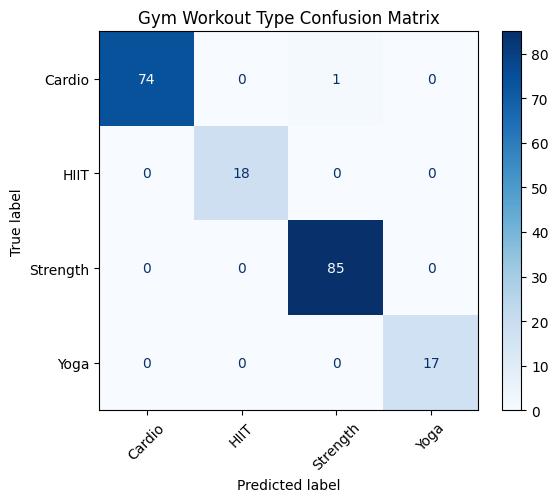

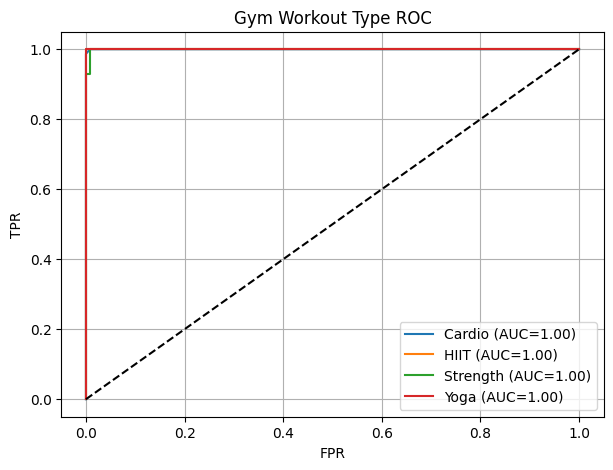

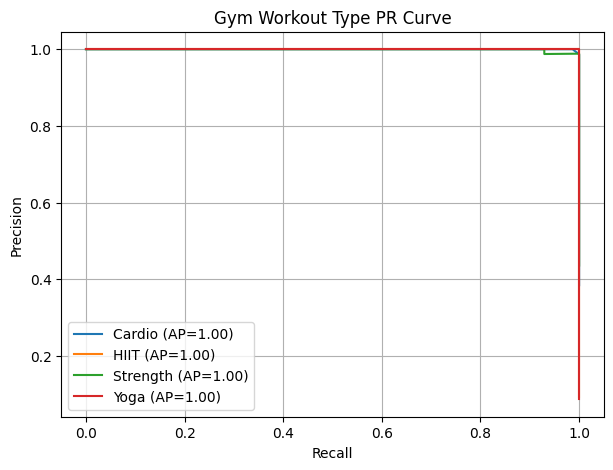


  REGRESSION REPORT — Gym — Calorie Burn
Calories_Burned              | MAE:   36.39 | RMSE:   47.96 | R²:0.9724

  CLASSIFICATION REPORT — Diet — Meal Plan
Accuracy: 96.92%
                   precision    recall  f1-score   support

    Balanced Diet       0.97      0.99      0.98       446
High-Protein Diet       0.97      0.90      0.93       139

         accuracy                           0.97       585
        macro avg       0.97      0.95      0.96       585
     weighted avg       0.97      0.97      0.97       585



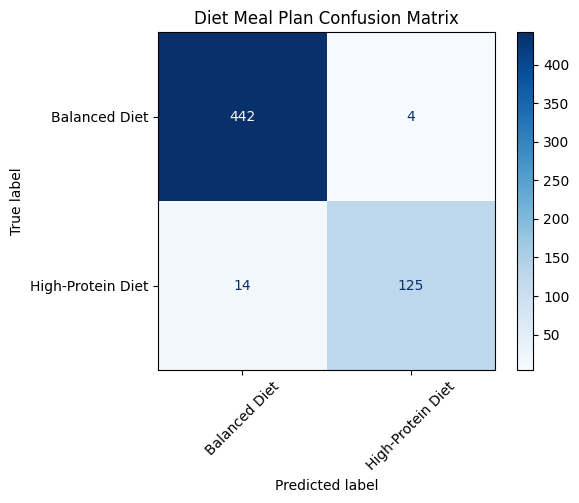

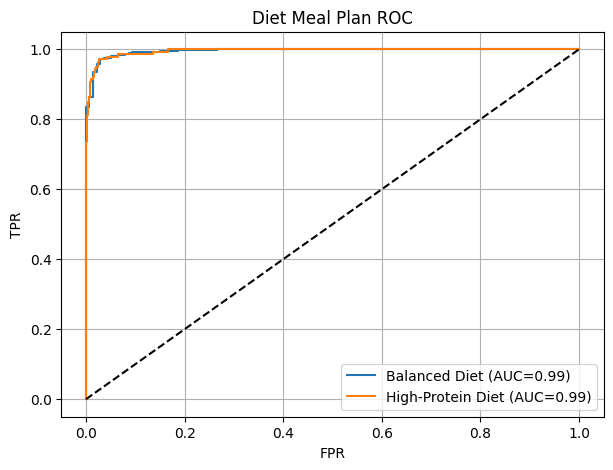

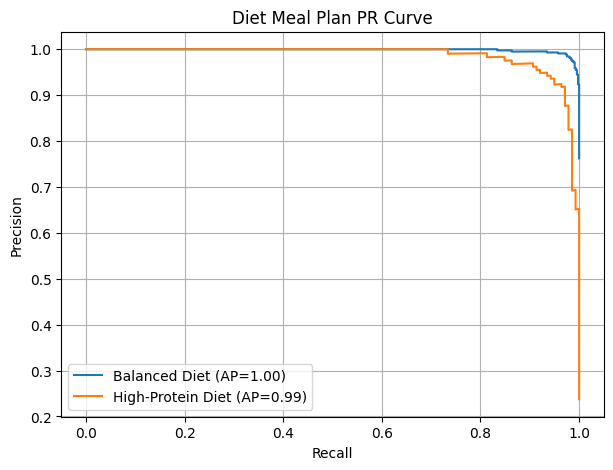


  REGRESSION REPORT — Diet — Macro Targets
Rec_Calories                 | MAE:    0.58 | RMSE:    2.43 | R²:0.9998
Rec_Protein                  | MAE:    0.06 | RMSE:    0.17 | R²:1.0000
Rec_Carbs                    | MAE:    0.07 | RMSE:    0.25 | R²:0.9999
Rec_Fats                     | MAE:    0.01 | RMSE:    0.03 | R²:1.0000

  CLASSIFICATION REPORT — Exercise — Intensity
Accuracy: 95.74%
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        11
           2       0.89      1.00      0.94         8
           3       1.00      0.83      0.91        12
           4       0.86      1.00      0.92         6
           5       1.00      1.00      1.00        10

    accuracy                           0.96        47
   macro avg       0.95      0.97      0.95        47
weighted avg       0.96      0.96      0.96        47



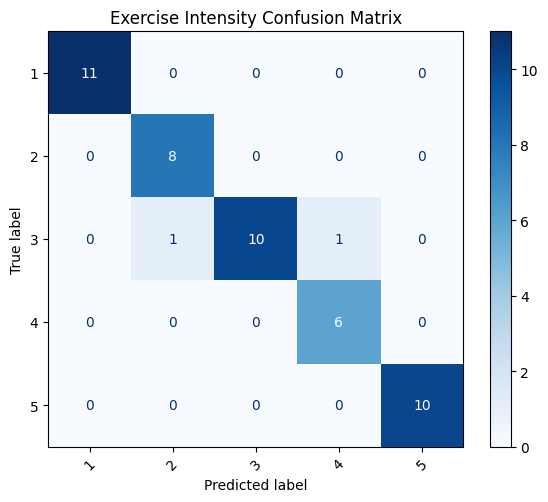

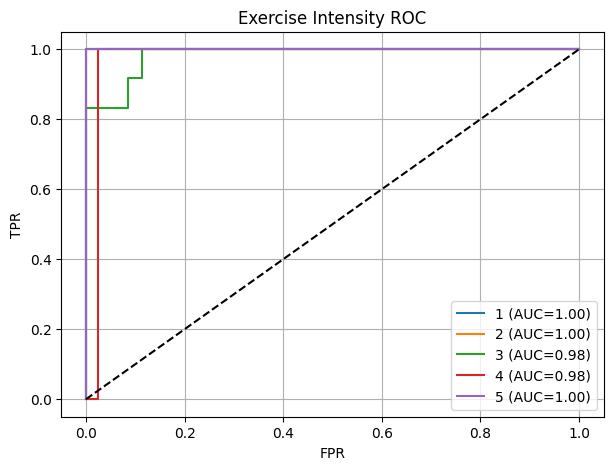

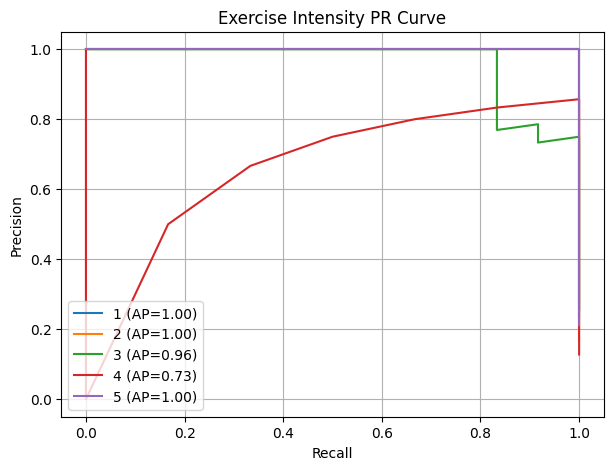


  REGRESSION REPORT — Exercise — Calorie Burn
Calories_Burn                | MAE:  469.23 | RMSE:  590.12 | R²:0.3718

  REGRESSION REPORT — Survey — Adherence Score
Adherence_Score              | MAE:    0.32 | RMSE:    0.43 | R²:0.9716

[STEP 7] Building 4-way fused embeddings …

[STEP 8] Training Health State HMM …

[STEP 9] Training RL agent (PPO, 20 000 steps) …

[STEP 10] Saving all models …
[INFO] All models saved to saved_models/

[STEP 11] Sample recommendation …

════════════════════════════════════════════════════════════════
   PERSONALISED FITNESS & DIET RECOMMENDATION
════════════════════════════════════════════════════════════════

  ── GYM ──────────────────────────────────────
  Workout Type        : Strength
  Session Calorie Burn: 874.6 kcal

  ── DIET ─────────────────────────────────────
  Meal Plan           : Balanced Diet
  Daily Calories      : 1980 kcal
  Protein             : 110 g
  Carbohydrates       : 234 g
  Fats                : 65 g

  ── EXERCISE ───

In [ ]:
# ==========================================================
# 10. MAIN — RUN THE FULL PIPELINE
# ==========================================================
print("\n" + "═"*64)
print("  PERSONALIZED FITNESS & DIET RECOMMENDATION  v4")
print("═"*64 + "\n")

# ── Load
print("[STEP 1] Loading datasets …")
datasets = load_datasets()

# ── Preprocess
print("\n[STEP 2] Preprocessing …")
gp = GymPreprocessor()
X_gym, y_gym_clf, y_gym_reg = gp.fit_transform(datasets["gym"])
n_wt = len(np.unique(y_gym_clf))

dp = DietPreprocessor()
X_diet, y_diet_reg, y_diet_clf = dp.fit_transform(datasets["diet"])
n_meal = len(np.unique(y_diet_clf))

ep = ExercisePreprocessor()
X_exer, y_exer_reg, y_exer_clf = ep.fit_transform(datasets["exer"])
n_intn = len(np.unique(y_exer_clf))

sp = SurveyPreprocessor()
X_survey, y_survey = sp.fit_transform(datasets["survey"])

print(f"  Gym    {X_gym.shape}   workout classes = {n_wt}")
print(f"  Diet   {X_diet.shape}   meal-plan classes = {n_meal}")
print(f"  Exer   {X_exer.shape}   intensity classes = {n_intn}")
print(f"  Survey {X_survey.shape}")

# ── Train
print("\n[STEP 3] Training Gym model …")
gym_clf, gym_reg, gym_eval = train_gym_model(X_gym, y_gym_clf, y_gym_reg, n_wt)

print("\n[STEP 4] Training Diet model …")
diet_clf, diet_reg, diet_eval = train_diet_model(X_diet, y_diet_reg, y_diet_clf, n_meal)

print("\n[STEP 5] Training Exercise model …")
exer_clf, exer_reg, exer_eval = train_exercise_model(X_exer, y_exer_reg, y_exer_clf, n_intn)

print("\n[STEP 6] Training Survey model …")
_, survey_reg, survey_eval = train_survey_model(X_survey, y_survey)

# ══════════════════════════════════════════════════════════
# EVALUATION REPORTS
# ══════════════════════════════════════════════════════════
print("\n\n" + "█"*64)
print("  FULL TEST-SET EVALUATION REPORTS")
print("█"*64)

_, yc_te, yr_te, clf_pred, clf_probs, reg_pred = gym_eval
evaluate_classifier("Gym — Workout Type", yc_te, clf_pred, gp.le_wtype.classes_.tolist())
plot_confusion_matrix(yc_te, clf_pred, gp.le_wtype.classes_, "Gym Workout Type Confusion Matrix")
plot_multiclass_roc(yc_te, clf_probs, gp.le_wtype.classes_, "Gym Workout Type ROC")
plot_precision_recall(yc_te, clf_probs, gp.le_wtype.classes_, "Gym Workout Type PR Curve")
evaluate_regressor("Gym — Calorie Burn", yr_te, reg_pred, ["Calories_Burned"])

_, yc_te, yr_te, clf_pred, clf_probs, reg_pred = diet_eval
evaluate_classifier("Diet — Meal Plan", yc_te, clf_pred, dp.le_plan.classes_.tolist())
plot_confusion_matrix(yc_te, clf_pred, dp.le_plan.classes_, "Diet Meal Plan Confusion Matrix")
plot_multiclass_roc(yc_te, clf_probs, dp.le_plan.classes_, "Diet Meal Plan ROC")
plot_precision_recall(yc_te, clf_probs, dp.le_plan.classes_, "Diet Meal Plan PR Curve")
evaluate_regressor("Diet — Macro Targets", yr_te, reg_pred,
                   ["Rec_Calories","Rec_Protein","Rec_Carbs","Rec_Fats"])

_, yc_te, yr_te, clf_pred, clf_probs, reg_pred = exer_eval
evaluate_classifier("Exercise — Intensity", yc_te, clf_pred,
                    [str(c) for c in ep.le_intens.classes_])
plot_confusion_matrix(yc_te, clf_pred, ep.le_intens.classes_, "Exercise Intensity Confusion Matrix")
plot_multiclass_roc(yc_te, clf_probs, ep.le_intens.classes_, "Exercise Intensity ROC")
plot_precision_recall(yc_te, clf_probs, ep.le_intens.classes_, "Exercise Intensity PR Curve")
evaluate_regressor("Exercise — Calorie Burn", yr_te, reg_pred, ["Calories_Burn"])

_, y_te, reg_pred = survey_eval
evaluate_regressor("Survey — Adherence Score", y_te, reg_pred, ["Adherence_Score"])

# ── Fusion + HMM
print("\n[STEP 7] Building 4-way fused embeddings …")
fused, fusion_pca = build_fused_embeddings(X_gym, X_diet, X_exer, X_survey)

print("\n[STEP 8] Training Health State HMM …")
hmm_est = HealthStateEstimator()
hmm_est.fit(fused)

# ── RL
print("\n[STEP 9] Training RL agent (PPO, 20 000 steps) …")
vec_env  = make_vec_env(FitnessDietEnv, n_envs=4, seed=SEED)
rl_model = PPO("MlpPolicy", vec_env, verbose=0, seed=SEED,
               learning_rate=3e-4, n_steps=512, batch_size=64)
rl_model.learn(total_timesteps=20_000)

# ── Save
print("\n[STEP 10] Saving all models …")
save_all(gym_clf, gym_reg, diet_clf, diet_reg, exer_clf, exer_reg, survey_reg,
         hmm_est, rl_model, fusion_pca, gp, dp, ep, sp)

# ── Sample recommendation
print("\n[STEP 11] Sample recommendation …")
engine = RecommendationEngine(
    gym_clf, gym_reg, diet_clf, diet_reg, exer_clf, exer_reg, survey_reg,
    hmm_est, rl_model, fusion_pca, gp, dp, ep, sp
)

gym_row = {
    "Age":28, "Gender":gp.le_gender.classes_[0], "Weight (kg)":70.0,
    "Height (m)":1.72, "Max_BPM":178, "Avg_BPM":148, "Resting_BPM":60,
    "Session_Duration (hours)":1.1, "Fat_Percentage":20.0,
    "Water_Intake (liters)":2.5, "Workout_Frequency (days/week)":4,
    "Experience_Level":2, "BMI":23.7,
    "Calories_Burned":0, "Workout_Type":"Dummy",
}
diet_row = {
    "Age":28, "Height_cm":172, "Weight_kg":70, "BMI":23.7,
    "Blood_Pressure_Systolic":118, "Blood_Pressure_Diastolic":76,
    "Cholesterol_Level":180, "Blood_Sugar_Level":88,
    "Daily_Steps":8500, "Exercise_Frequency":4, "Sleep_Hours":7.5,
    "Caloric_Intake":2200, "Protein_Intake":100,
    "Carbohydrate_Intake":260, "Fat_Intake":72,
    "Gender":dp.cat_les["Gender"].classes_[0],
    "Genetic_Risk_Factor":dp.cat_les["Genetic_Risk_Factor"].classes_[0],
    "Alcohol_Consumption":dp.cat_les["Alcohol_Consumption"].classes_[0],
    "Smoking_Habit":dp.cat_les["Smoking_Habit"].classes_[0],
    "Dietary_Habits":dp.cat_les["Dietary_Habits"].classes_[0],
    "Recommended_Calories":0, "Recommended_Protein":0,
    "Recommended_Carbs":0, "Recommended_Fats":0,
    "Recommended_Meal_Plan":"Dummy",
}
exer_row = {
    "Age":28, "Duration":45, "Heart Rate":152, "BMI":23.7,
    "Dream Weight":68.0, "Actual Weight":70.0,
    "Gender":ep.le_gender.classes_[0],
    "Weather Conditions":ep.le_weather.classes_[0],
    "Exercise":ep.le_exer.classes_[0],
}
survey_row = {
    "age":28, "phy_ff":5, "phy_health":8, "phy_bw":7, "phy_ex":8,
    "height":172.0, "weight":70, "fruit":3, "veg":3, "cook":2,
    "spend":3000, "income":60000, "rate":5,
    "sex":sp.le_sex.classes_[0],
    "work":sp.le_work.classes_[0],
    "gymtime":sp.le_gym.classes_[0],
    "disease":sp.le_dis.classes_[0],
}

rec = engine.recommend(gym_row, diet_row, exer_row, survey_row)
print_recommendation(rec)

# 1. GENERATE THE RECOMMENDATION
rec = engine.recommend(gym_row, diet_row, exer_row, survey_row)
print_recommendation(rec)

# 2. RUN THE SINGLE-USER METRICS DISPLAY
print("\n" + "█"*64)
print("  RECOMMENDATION SYSTEM PERFORMANCE METRICS")
print("█"*64)

# We merge the dictionaries to provide the safety_check with all required keys
combined_user_data = {**gym_row, **diet_row, **exer_row, **survey_row}

satisfaction = calculate_satisfaction_score(rec)
consistency = consistency_check(rec)
actionability = calculate_actionability(rec)
safety = safety_check(rec, combined_user_data)

print(f"\nRECOMMENDATION QUALITY SCORES:")
print(f"  * Satisfaction Potential: {satisfaction:.2f}/1.0  {'[PASS]' if satisfaction > 0.7 else '[WARN]'}")
print(f"  * Internal Consistency:   {consistency:.2f}/1.0  {'[PASS]' if consistency > 0.7 else '[WARN]'}")
print(f"  * Actionability:          {actionability:.2f}/1.0  {'[PASS]' if actionability > 0.7 else '[WARN]'}")
print(f"  * Safety Check:           {'[PASSED]' if safety['is_safe'] else '[FAILED]'}")

print(f"\nINTERPRETATION:")
if all([satisfaction > 0.7, consistency > 0.7, actionability > 0.7, safety['is_safe']]):
    print("  EXCELLENT: This recommendation is high-quality and safe to follow.")
elif satisfaction > 0.5 and consistency > 0.5:
    print("  GOOD: This recommendation is reasonable but could be improved.")
else:
    print("  NEEDS IMPROVEMENT: Consider adjusting the model parameters.")

# 3. RUN THE FULL SYSTEM EVALUATION
# Wrap the dummy user into a list to act as 'test_users'
test_users = [{
    'gym': gym_row,
    'diet': diet_row,
    'exer': exer_row,
    'survey': survey_row
}]

evaluation = evaluate_recommendation_system(engine, test_users)

print("\n" + "═"*64)
print("  SYSTEM-WIDE EVALUATION METRICS")
print("═"*64)
print(f"Safety Compliance: {evaluation.get('safety_percentage', 0):.1f}%")
print(f"Average Consistency: {evaluation['avg_consistency']:.2f}/1.0")
print(f"Recommendation Diversity: {evaluation['diversity']:.2f}")
print(f"Personalization Score: {evaluation['avg_personalization']:.2f}")